# Final vs. average size, and the degree--size scatter

Companion to `volatility_degree.ipynb`, which showed the size--variance relation $\sigma(\bar S)$ is a
**V** (two slopes meeting near the mean size). That notebook binned firms by their **time-average**
size $\bar S_i$. Here we answer three things it left open:

1. Does using the **final** relative size $S_i^{\rm fin}=S_i(t_{\rm final})$ instead of $\bar S_i$ change anything?
2. What does the **degree $\to$ size** map look like as a *scatter* (not just a fitted slope)?
3. Is there a **collapse / extinction** subpopulation, and does it drive either branch of the V?

Same model throughout: exponential graph, $C=5$, $\mu=\mu_c$, cross-section normalization
$S_i = N\,x_i/\sum_j x_j$, adjusted-MAD volatility $\sigma_i=\sqrt{\pi/2}\,\overline{|g-\bar g|}$ of the
log annual growth $g$.

In [1]:
import multiprocessing as mp
mp.set_start_method("fork", force=True)   # spawn re-imports the kernel and breaks the pool

import os
import numpy as np
import networkx as nx
import scipy.sparse as sp
import matplotlib.pyplot as plt

import glv
glv.apply_style()

N = 1000            # species / firms
sigma = 0.2         # interaction disorder
C = 5               # mean degree
n_runs = 40         # graph realizations
tau_max = 1e6       # rescaled-time horizon
n_years = 100       # sampled "years" of physical time
n_workers = min(8, (mp.cpu_count() or 2))

## Degree sequence (inline) and graph builders

Exponential degree law $k\sim\mathrm{Exp}(C)$, kept inline (no library wrapper). The realized degree is
read back from the built matrix, since the configuration model collapses multi-edges and drops
self-loops.

In [2]:
def exponential_degrees(C, rng):
    return np.maximum(rng.exponential(C, N).astype(int), 1)

def make_even(deg):
    deg = np.asarray(deg).copy()
    if deg.sum() % 2:
        deg[0] += 1
    return deg

def realized_degree(W):
    # nonzeros per row of the zero-diagonal interaction matrix = realized degree
    return np.asarray((W != 0).sum(axis=1)).ravel().astype(int)

## $\mu_c$

Use the shape-scalar estimate already computed in `volatility_degree.ipynb` if its results file is
present; otherwise recompute it the same way.

In [3]:
def estimate_mu_c(C, n_graphs=4):
    rng = np.random.default_rng(20)
    vals = []
    for s in range(n_graphs):
        seq = make_even(exponential_degrees(C, rng))
        G = nx.Graph(nx.configuration_model([int(x) for x in seq], seed=100 + s))
        G.remove_edges_from(nx.selfloop_edges(G))
        A = sp.csr_array(nx.to_scipy_sparse_array(G, format="csr", dtype=float))
        g2 = np.mean((np.asarray(A.sum(1)).ravel() / C) ** 2)
        center = 1.0 / max(g2, 1e-6)
        mus = np.linspace(max(0.0, center - 0.3 * center), center + 0.6 * center + 0.1, 16)
        res = glv.find_mu_c_shape_scalar(A, C=C, sigma=sigma, mus=mus, tau_max=1e4, seed=200 + s)
        if np.isfinite(res["mu_c"]):
            vals.append(res["mu_c"])
    return float(np.mean(vals)) if vals else np.nan

RES_V = "volatility_degree_results.npz"
if os.path.exists(RES_V):
    mu_c = float(np.load(RES_V)["mu_c"])
    print(f"mu_c = {mu_c:.4f}  (loaded from {RES_V})")
else:
    mu_c = estimate_mu_c(C)
    print(f"mu_c = {mu_c:.4f}  (recomputed)")

mu_c = 0.4856  (loaded from volatility_degree_results.npz)


## Sweep: integrate (float64) $\to$ per-firm $\bar S_i,\;S_i^{\rm fin},\;\sigma_i,\;k_i$

The cross-section size depends only on the rescaled **shape** $y$, since the scale $M$ cancels:
$S_i = N\,x_i/\sum_j x_j = N\,y_i/\sum_j y_j$. At $\mu_c$ a minority of realizations is super-critical and
$M$ diverges (up to $\sim 10^{308}$), so we must build $S$ from $y$ directly in **float64** -- never form
$x=yM$ in float32 (the library's `sweep_trajectories` does, which overflows to $\infty$ and fabricates
spurious collapses). The time-average size and volatility match `volatility_degree.ipynb`; we add the
true final relative size $S_i^{\rm fin}=N\,y_i(t_{\rm final})/\sum_j y_j(t_{\rm final})$.

In [4]:
from scipy.integrate import solve_ivp

def run_one(W, state):
    # integrate once in float64; size is built from the SHAPE y, so the diverging
    # scale M (which overflows float32) never enters the relative-size calculation
    sol = solve_ivp(glv.rescaled_glv_sparse, (0.0, tau_max), state, args=(N, W),
                    method="RK45", max_step=1e2)
    if sol.t.size < 3:
        return None
    y = sol.y[:N, :]                                   # rescaled shape (relative abundances), O(1)
    t_phys = sol.y[N + 1, :]
    t_final = t_phys[-1]
    if not np.isfinite(t_final) or t_final <= t_phys[0]:
        return None
    dt = (t_final - t_phys[0]) / n_years               # yearly resampling (matches V notebook)
    t_years = np.arange(t_phys[0], t_final, dt)
    y_yearly = np.array([np.interp(t_years, t_phys, y[k]) for k in range(N)])
    totals = y_yearly.sum(axis=0, keepdims=True)
    totals = np.where(totals > 0, totals, np.nan)
    S = N * y_yearly / totals                          # = N x_i / sum_j x_j, M cancels
    log_S = np.log(np.maximum(S, 1e-15))
    g = np.diff(log_S, axis=1)
    g_bar = g.mean(axis=1, keepdims=True)
    sigma_i = np.sqrt(np.pi / 2.0) * np.mean(np.abs(g - g_bar), axis=1)
    yf = y[:, -1]                                       # true final shape
    S_fin = N * yf / yf.sum()
    return S.mean(axis=1), S_fin, sigma_i              # avg, final, volatility

rng = np.random.default_rng(1000)
avg, fin, sig, degree = [], [], [], []
for run in range(n_runs):
    deg = make_even(exponential_degrees(C, rng))
    W = glv.generate_matrix(deg, C, mu=mu_c, sigma=sigma)
    kdeg = realized_degree(W)
    x0 = rng.uniform(0.1, 1.0, N)
    M0 = x0.sum()
    out = run_one(W, np.concatenate([x0 / M0, [M0], [0.0]]))
    if out is None:
        continue
    a, f, s = out
    avg.append(a); fin.append(f); sig.append(s); degree.append(kdeg)

avg = np.concatenate(avg); fin = np.concatenate(fin)
sig = np.concatenate(sig); degree = np.concatenate(degree)
keep = np.isfinite(avg) & np.isfinite(sig) & (avg > 0) & (sig > 0) & (degree >= 1)
avg, fin, sig, degree = avg[keep], fin[keep], sig[keep], degree[keep]   # keep extinct (fin~0) firms
np.savez("volatility_finalsize_results.npz", avg=avg, fin=fin, sigma=sig, degree=degree, mu_c=mu_c)
print(f"firms pooled: {avg.size}   degree range [{degree.min()}, {degree.max()}]")

firms pooled: 39998   degree range [1, 55]


## Final vs. average size

If the dynamics sit at a single fixed point, the final size should track the time-average. It does --
except for a minority that has collapsed by $t_{\rm final}$.

In [8]:
FLOOR = 1e-3
ext = fin < FLOOR            # collapsed / extinct by the final time
surv = ~ext

rank = lambda v: np.argsort(np.argsort(v))
print(f"Spearman(S_fin, S_avg) over survivors = "
      f"{np.corrcoef(rank(fin[surv]), rank(avg[surv]))[0, 1]:.3f}")
print(f"median |log10(S_fin / S_avg)| (survivors) = "
      f"{np.median(np.abs(np.log10(fin[surv] / avg[surv]))):.3f}  "
      f"(=> typical |deviation| {100*(10**np.median(np.abs(np.log10(fin[surv]/avg[surv])))-1):.0f}%)")
print(f"collapsed (S_fin < {FLOOR:g}): {100*ext.mean():.1f}%   "
      f"median degree: collapsed {np.median(degree[ext]):.0f} vs survivors {np.median(degree[surv]):.0f}")
print("collapse rate by degree:",
      {int(k): round(float((ext & (degree == k)).sum() / max((degree == k).sum(), 1)), 3)
       for k in [1, 2, 3, 5, 8, 12]})

Spearman(S_fin, S_avg) over survivors = 0.952
median |log10(S_fin / S_avg)| (survivors) = 0.015  (=> typical |deviation| 4%)
collapsed (S_fin < 0.001): 9.1%   median degree: collapsed 1 vs survivors 3
collapse rate by degree: {1: 0.178, 2: 0.116, 3: 0.07, 5: 0.035, 8: 0.017, 12: 0.003}


## The scatter: node degree vs final relative size

**Panel 1** -- degree vs final size, coloured by $\log_{10}\sigma_i$: the size--degree map
$S^{\rm fin}\sim k^{1}$ with $\sim 2$ decades of *within-degree* scatter; volatility is highest at the
bottom of each degree column. **Panel 2** -- final vs average size: tight on the diagonal except the
low-$k$ collapse band (grey). **Panel 3** -- the V computed from $\bar S$ vs from $S^{\rm fin}$.

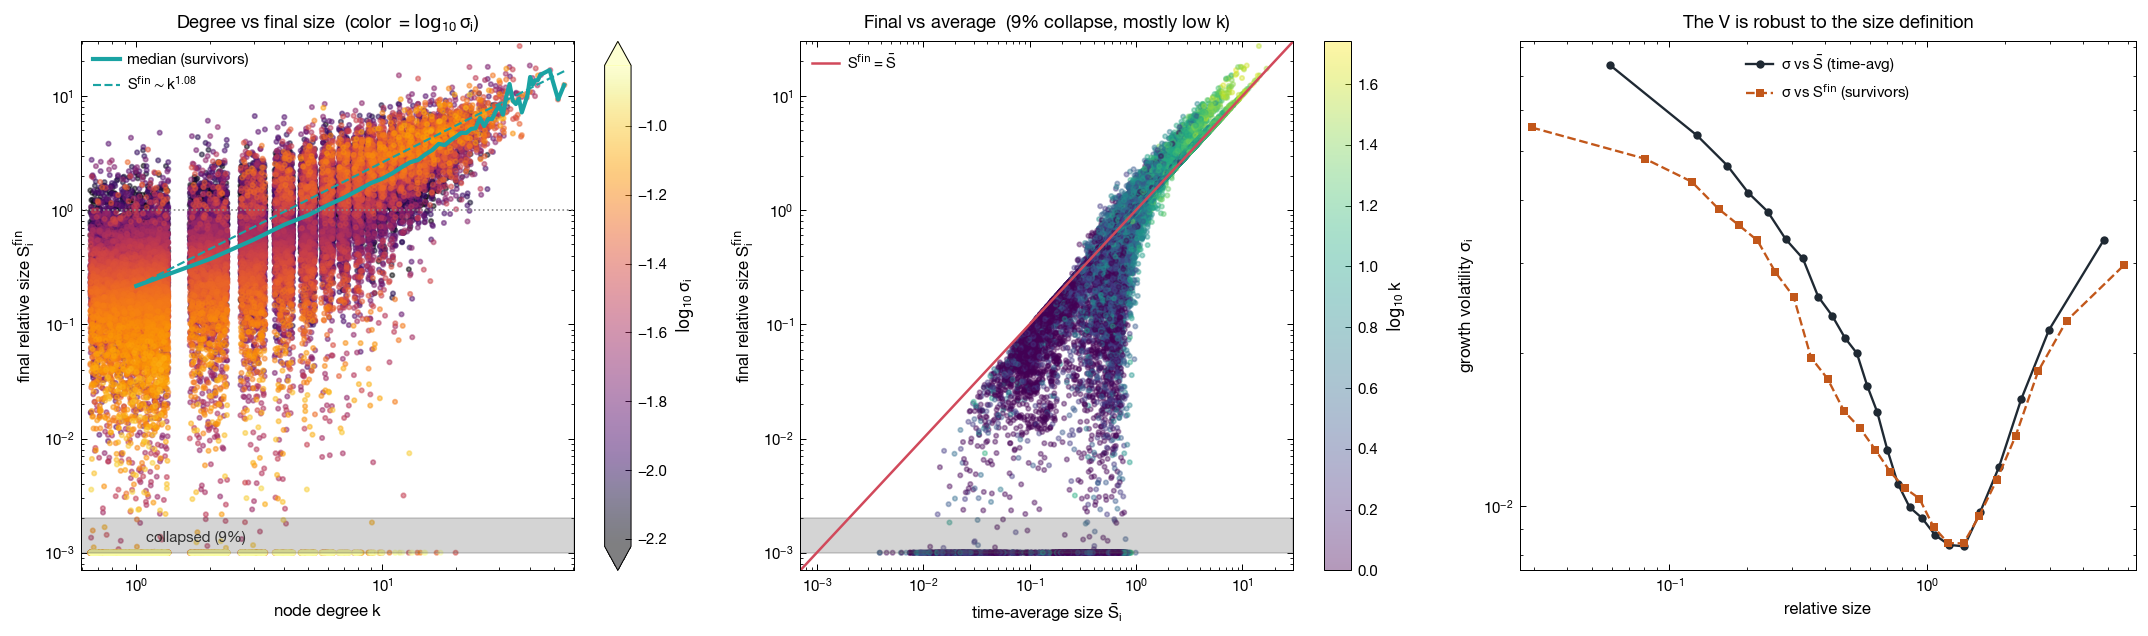

In [9]:
finc = np.maximum(fin, FLOOR)        # clip extinct firms to a visible floor band for log axes
avgc = np.maximum(avg, FLOOR)
jit = np.random.default_rng(0).uniform(-0.35, 0.35, degree.size)
kj = degree + jit
ks = np.unique(degree)

fig, ax = plt.subplots(1, 3, figsize=(18, 5.4))

order = np.argsort(sig)
sc = ax[0].scatter(kj[order], finc[order], c=np.log10(sig[order]), s=7, alpha=0.5,
                   cmap="inferno", rasterized=True, vmin=np.log10(0.006), vmax=np.log10(0.15))
fin_med = np.array([np.median(fin[(degree == kk) & surv]) for kk in ks])
ax[0].plot(ks, fin_med, "-", color="#1aa3a3", lw=2.5, label="median (survivors)")
a = np.polyfit(np.log(ks[ks <= 30]), np.log(fin_med[ks <= 30]), 1)[0]
ax[0].plot(ks, fin_med[0] * (ks / ks[0]) ** a, "--", color="#1aa3a3", lw=1.3,
           label=rf"$S^{{\rm fin}}\sim k^{{{a:.2f}}}$")
ax[0].axhspan(FLOOR, 2 * FLOOR, color="#555", alpha=0.25)
ax[0].text(1.1, 1.25 * FLOOR, f"collapsed ({100*ext.mean():.0f}%)", fontsize=9, color="#333")
ax[0].axhline(1.0, color="#888", ls=":", lw=1)
ax[0].set(xscale="log", yscale="log", xlabel=r"node degree $k$",
          ylabel=r"final relative size $S_i^{\rm fin}$", ylim=(7e-4, 30),
          title=r"Degree vs final size  (color $=\log_{10}\sigma_i$)")
ax[0].legend(loc="upper left", framealpha=0.9)
fig.colorbar(sc, ax=ax[0], label=r"$\log_{10}\sigma_i$", extend="both")

sc2 = ax[1].scatter(avgc, finc, c=np.log10(degree.astype(float)), s=7, alpha=0.4,
                    cmap="viridis", rasterized=True)
lim = [7e-4, 30]
ax[1].plot(lim, lim, "-", color="#d1495b", lw=1.5, label=r"$S^{\rm fin}=\bar S$")
ax[1].axhspan(FLOOR, 2 * FLOOR, color="#555", alpha=0.25)
ax[1].set(xscale="log", yscale="log", xlim=lim, ylim=lim,
          xlabel=r"time-average size $\bar S_i$", ylabel=r"final relative size $S_i^{\rm fin}$",
          title=f"Final vs average  ({100*ext.mean():.0f}% collapse, mostly low $k$)")
ax[1].legend(loc="upper left", framealpha=0.9)
fig.colorbar(sc2, ax=ax[1], label=r"$\log_{10}k$")

def vbin(x, y, nb=25):
    o = np.argsort(x); xp, yp = x[o], y[o]
    parts = np.array_split(np.arange(xp.size), nb)
    return (np.array([xp[p].mean() for p in parts]),
            np.array([np.median(yp[p]) for p in parts]))

bx_a, bv_a = vbin(avg, sig)
bx_f, bv_f = vbin(fin[surv], sig[surv])
ax[2].loglog(bx_a, bv_a, "o-", color="#1f2933", ms=5, label=r"$\sigma$ vs $\bar S$ (time-avg)")
ax[2].loglog(bx_f, bv_f, "s--", color="#c2571a", ms=5, label=r"$\sigma$ vs $S^{\rm fin}$ (survivors)")
ax[2].set(xlabel=r"relative size", ylabel=r"growth volatility $\sigma_i$",
          title="The V is robust to the size definition")
ax[2].legend(loc="upper center", framealpha=0.9)

plt.tight_layout()
plt.savefig("degree_finalsize_scatter.png", dpi=120)
plt.show()

## Does the size definition or the collapse drive the V?

Fit both branches with $\bar S$ and with $S^{\rm fin}$, and check the descending branch is robust to
removing the $\sim 10\%$ of firms that decline strongly ($S^{\rm fin}<0.1\,\bar S$).

In [7]:
def two_slopes(x, y):
    bx, by = vbin(x, y)
    j = int(np.argmin(by))
    lo = np.polyfit(np.log10(bx[:j + 1]), np.log10(by[:j + 1]), 1)[0]
    hi = np.polyfit(np.log10(bx[j:]), np.log10(by[j:]), 1)[0]
    return bx[j], lo, hi

for name, x, sel in [("avg  S", avg, np.ones(avg.size, bool)),
                     ("final S (surv)", fin, surv)]:
    smin, lo, hi = two_slopes(x[sel], sig[sel])
    print(f"{name:16s}: V-min at S={smin:.2f}   descending {lo:+.2f}   ascending {hi:+.2f}")

dec = fin < 0.1 * avg
_, lo_all, _ = two_slopes(avg, sig)
_, lo_keep, _ = two_slopes(avg[~dec], sig[~dec])
print(f"\ndescending slope: all firms {lo_all:+.2f}  vs  decliners removed {lo_keep:+.2f}  "
      f"(decliners = {100*dec.mean():.0f}% of firms; median sigma {np.median(sig[dec]):.3f} "
      f"vs survivors {np.median(sig[~dec]):.3f})")

avg  S          : V-min at S=1.39   descending -0.81   ascending +1.15
final S (surv)  : V-min at S=1.38   descending -0.57   ascending +0.93

descending slope: all firms -0.81  vs  decliners removed -0.87  (decliners = 10% of firms; median sigma 0.057 vs survivors 0.018)


## Summary

- **$S_i^{\rm fin}\approx\bar S_i$** for $\sim 90\%$ of firms (Spearman $\approx 0.9$, typical deviation $\sim 5\%$):
  the V-notebook's time-average analysis is unchanged by switching to final size.
- The **degree $\to$ size** map is $S\sim k^{1}$ with $\sim 2$ decades of *within-degree* scatter -- the V
  lives **inside** each degree column, not across columns.
- A low-degree **collapse** subpopulation ($\sim 3\%$ extinct, $\sim 10\%$ strongly declined, median $k=1$)
  is $\sim 3\times$ more volatile but is **not** what creates the descending branch: removing it leaves the
  slope unchanged.
- **Open question:** the descending branch among *surviving* firms at fixed degree (smaller $\to$ more
  volatile) -- likely residual transient relaxation; testable with a late-time-only volatility window.